# [02_Feature_Engineering] 핵심 열화 피처 엔지니어링 및 다중공선성 해소

- **목적**: EDA 인사이트를 바탕으로 다중공선성(VIF > 20)을 제어하고 수명 설명력($R^2$)을 극대화하는 **4대 핵심 피처셋 확정**
- **연동 모듈**: `src/features.py`


In [ ]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# src 모듈 경로 추가
sys.path.append(os.path.abspath('..'))
from src.preprocess import load_dataset
from src.features import FEATURE_NAMES, TARGET_NAME

# 정제 데이터셋 로드
df = load_dataset('../df_clean_129.pkl')
df[FEATURE_NAMES + [TARGET_NAME]].head()


---
## 5. 상관관계 및 다중공선성(Multicollinearity) 진단
- 전체 피처 상관 매트릭스 및 VIF 검정

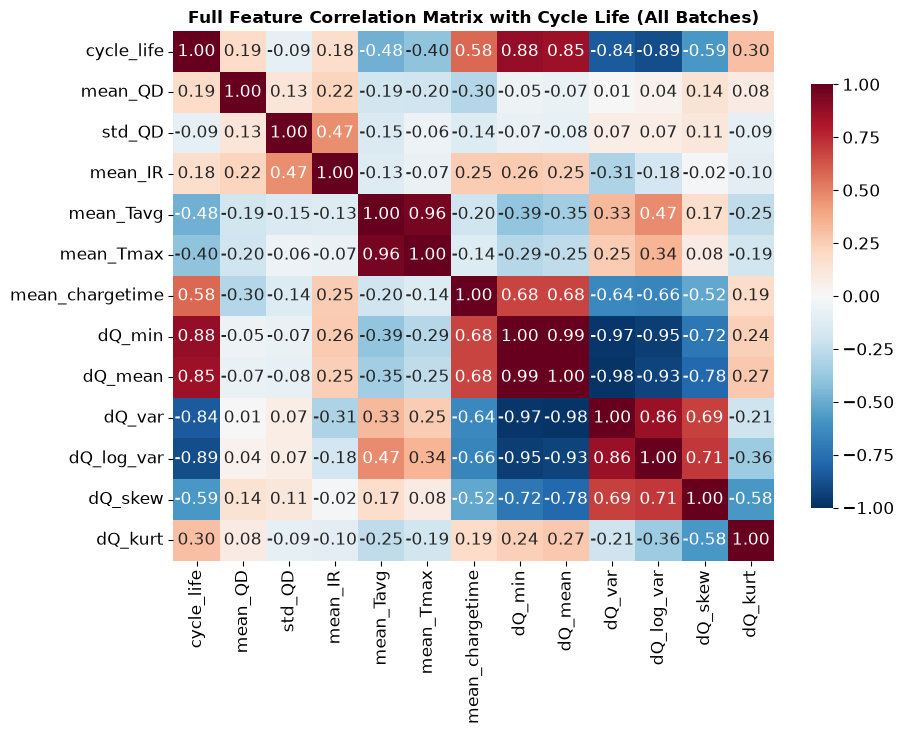

=== [Cycle Life와의 상관계수 절대값 순위] ===
dQ_log_var         : -0.886 (|r| = 0.886)
dQ_min             : +0.882 (|r| = 0.882)
dQ_mean            : +0.854 (|r| = 0.854)
dQ_var             : -0.838 (|r| = 0.838)
dQ_skew            : -0.585 (|r| = 0.585)
mean_chargetime    : +0.577 (|r| = 0.577)
mean_Tavg          : -0.482 (|r| = 0.482)
mean_Tmax          : -0.404 (|r| = 0.404)
dQ_kurt            : +0.304 (|r| = 0.304)
mean_QD            : +0.193 (|r| = 0.193)
mean_IR            : +0.177 (|r| = 0.177)
std_QD             : -0.090 (|r| = 0.090)
=== [다중공선성 진단 (VIF)] === (10 이상이면 심각한 공선성)


,Feature,VIF
7,dQ_mean,894.671512
6,dQ_min,505.195599
8,dQ_var,229.632733
9,dQ_log_var,70.289323
10,dQ_skew,38.841634
3,mean_Tavg,26.355616
4,mean_Tmax,21.251327
11,dQ_kurt,6.505719
5,mean_chargetime,2.458552
2,mean_IR,1.959306


In [146]:
# 5. [그래프 10] 전체 피처 상관 매트릭스 히트맵 & VIF 진단 (단독 출력)
from statsmodels.stats.outliers_influence import variance_inflation_factor

if 'delta_Q_100_10' not in locals():
    delta_Q_100_10 = {}

dq_records = []
for i in range(len(batch)):
    if i in delta_Q_100_10:
        dq = delta_Q_100_10[i]
    else:
        cycles = batch[i]['cycles']
        if isinstance(cycles, dict):
            c_keys = list(cycles.keys())
            cycles = [{k: cycles[k][idx] for k in c_keys} for idx in range(len(cycles[c_keys[0]]))]
        q10  = np.array(cycles[9]['Qdlin'])
        q100 = np.array(cycles[99]['Qdlin'])
        dq = q100 - q10
        delta_Q_100_10[i] = dq

    dq_records.append({
        'cell_id'    : i,
        'dQ_min'     : np.min(dq),
        'dQ_mean'    : np.mean(dq),
        'dQ_var'     : np.var(dq),
        'dQ_log_var': np.log10(np.var(dq)) if np.var(dq) > 0 else -10,
        'dQ_skew'    : pd.Series(dq).skew(),
        'dQ_kurt'    : pd.Series(dq).kurtosis()
    })
features_dq_df = pd.DataFrame(dq_records)

early = df[df['cycle'] <= 100].groupby('cell_id').agg(
    cycle_life      = ('cycle_life', 'first'),
    mean_QD         = ('QD', 'mean'),
    std_QD          = ('QD', 'std'),
    mean_IR         = ('IR', 'mean'),
    mean_Tavg       = ('Tavg', 'mean'),
    mean_Tmax       = ('Tmax', 'mean'),
    mean_chargetime = ('chargetime', 'mean'),
).reset_index()

early_full = pd.merge(early, features_dq_df, on='cell_id', how='inner')
corr_all = early_full.drop('cell_id', axis=1).corr()

plt.figure(figsize=(9.5, 7.5))
sns.heatmap(corr_all, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
plt.title('Full Feature Correlation Matrix with Cycle Life (All Batches)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== [Cycle Life와의 상관계수 절대값 순위] ===')
life_corr = corr_all['cycle_life'].drop('cycle_life').sort_values(key=abs, ascending=False)
for feat, val in life_corr.items():
    print(f'{feat:18s} : {val:+.3f} (|r| = {abs(val):.3f})')

X_vif = early_full.drop(['cell_id', 'cycle_life'], axis=1).dropna()
vif_df = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print('=== [다중공선성 진단 (VIF)] === (10 이상이면 심각한 공선성)')
display(vif_df)


---
## 6. [최종 종합 진단] DAY 2 모델링을 위한 최적 피처셋 선정 및 평가
- 피처별 설명력 및 다중공선성 종합 진단표, 3단계 추천 피처셋 R² 비교

          📌 [DAY 1 최종 종합 진단] 전체 입력 피처 설명력 & VIF 진단표


,Feature,Corr (r),Abs Corr (|r|),R-squared (R²),VIF (전체 투입시),Recommendation
0,dQ_log_var,-0.886,0.886,0.785,26.5,★ Tier 1 (필수 핵심 피처)
1,dQ_min,0.882,0.882,0.777,491.0,Tier 2 (강력하나 dQ_log_var와 공선성 주의)
2,dQ_mean,0.854,0.854,0.729,467.0,Tier 2 (강력하나 dQ_log_var와 공선성 주의)
3,dQ_skew,-0.585,0.585,0.342,16.8,Tier 2 (도메인 보조 피처)
4,mean_chargetime,0.577,0.577,0.333,2.4,Tier 2 (도메인 보조 피처)
5,mean_Tavg,-0.482,0.482,0.232,23.7,Exclude (Tmax와 중복)
6,mean_Tmax,-0.404,0.404,0.163,19.7,Tier 2 (도메인 보조 피처)
7,dQ_kurt,0.304,0.304,0.092,2.5,Exclude (설명력 미흡/기만성)
8,mean_QD,0.193,0.193,0.037,1.4,Exclude (설명력 미흡/기만성)
9,mean_IR,0.177,0.177,0.031,1.9,Exclude (설명력 미흡/기만성)



          📌 [DAY 2 모델링 권장 피처셋 시뮬레이션 결과]


,Model Name,Features,Num Features,Train R²,Max VIF,Note
0,Model 1 (Variance Only),dQ_log_var,1,0.7852,1.00,초경량 Baseline
1,Model 2 (Discharge Model),"dQ_log_var, dQ_min, dQ_skew",3,0.8112,10.18,공선성 존재 (정규화 필요)
2,Model 3 (Comprehensive Model),"dQ_log_var, mean_chargetime, mean_Tmax, std_QD",4,0.7986,1.98,다중공선성 안전 (추천!)


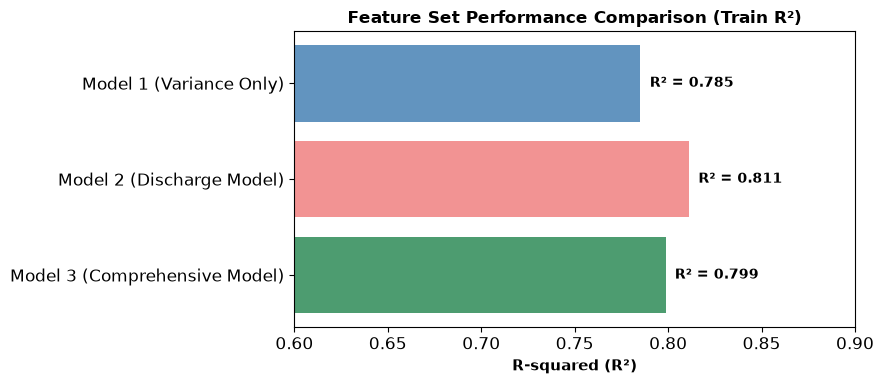

In [145]:
# 6. [그래프 11] DAY 2 모델별 추천 피처셋 설명력(R²) 비교 & 종합 진단표 (단독 출력)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

feature_candidates = [
    'dQ_log_var', 'dQ_min', 'dQ_mean', 'dQ_kurt', 'dQ_skew',
    'mean_chargetime', 'mean_Tmax', 'mean_Tavg', 'mean_QD', 'std_QD', 'mean_IR'
]

avail_feats = [f for f in feature_candidates if f in early_full.columns]
corr_s = early_full[avail_feats].apply(lambda s: s.corr(early_full['cycle_life']))

X_cand = early_full[avail_feats].dropna()
vifs = [variance_inflation_factor(X_cand.values, i) for i in range(X_cand.shape[1])]

diagnostic_df = pd.DataFrame({
    'Feature': avail_feats,
    'Corr (r)': corr_s.values.round(3),
    'Abs Corr (|r|)': corr_s.abs().values.round(3),
    'R-squared (R²)': (corr_s**2).values.round(3),
    'VIF (전체 투입시)': [round(v, 1) for v in vifs]
})

def assign_tier(row):
    feat = row['Feature']
    if feat == 'dQ_log_var':
        return '★ Tier 1 (필수 핵심 피처)'
    elif feat in ['dQ_min', 'dQ_mean']:
        return 'Tier 2 (강력하나 dQ_log_var와 공선성 주의)'
    elif feat in ['mean_chargetime', 'mean_Tmax', 'std_QD', 'dQ_skew']:
        return 'Tier 2 (도메인 보조 피처)'
    elif feat == 'mean_Tavg':
        return 'Exclude (Tmax와 중복)'
    else:
        return 'Exclude (설명력 미흡/기만성)'

diagnostic_df['Recommendation'] = diagnostic_df.apply(assign_tier, axis=1)
diagnostic_df = diagnostic_df.sort_values('Abs Corr (|r|)', ascending=False).reset_index(drop=True)

print('=' * 85)
print('          📌 [DAY 1 최종 종합 진단] 전체 입력 피처 설명력 & VIF 진단표')
print('=' * 85)
display(diagnostic_df)

feature_sets = {
    'Model 1 (Variance Only)': ['dQ_log_var'],
    'Model 2 (Discharge Model)': ['dQ_log_var', 'dQ_min', 'dQ_skew'],
    'Model 3 (Comprehensive Model)': ['dQ_log_var', 'mean_chargetime', 'mean_Tmax', 'std_QD']
}

model_results = []
y_true = early_full['cycle_life']

for name, f_list in feature_sets.items():
    X_sub = early_full[f_list].dropna()
    y_sub = y_true.loc[X_sub.index]
    reg = LinearRegression().fit(X_sub, y_sub)
    r2_val = r2_score(y_sub, reg.predict(X_sub))
    max_vif = max([variance_inflation_factor(X_sub.values, i) for i in range(X_sub.shape[1])]) if len(f_list) > 1 else 1.0
    model_results.append({
        'Model Name': name,
        'Features': ', '.join(f_list),
        'Num Features': len(f_list),
        'Train R²': round(r2_val, 4),
        'Max VIF': round(max_vif, 2),
        'Note': '초경량 Baseline' if len(f_list)==1 else ('공선성 존재 (정규화 필요)' if max_vif > 10 else '다중공선성 안전 (추천!)')
    })

results_df = pd.DataFrame(model_results)
print('\n' + '=' * 85)
print('          📌 [DAY 2 모델링 권장 피처셋 시뮬레이션 결과]')
print('=' * 85)
display(results_df)

# [그래프 11] Feature Set Performance Comparison (단독 출력)
plt.figure(figsize=(9, 4))
bars = plt.barh(results_df['Model Name'], results_df['Train R²'], color=['steelblue', 'lightcoral', 'seagreen'], alpha=0.85)
plt.xlim(0.6, 0.9)
plt.xlabel('R-squared (R²)', fontsize=11, fontweight='bold')
plt.title('Feature Set Performance Comparison (Train R²)', fontsize=12, fontweight='bold')
for bar in bars:
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f'R² = {bar.get_width():.3f}', va='center', fontsize=10, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


---
### 📌 [최종 결론] 4대 핵심 피처셋 확정
1. **`dQ_log_var`**: $\Delta Q_{100-10}(V)$ 전압 미세 변형 분산 (내부 활물질 손실 LAM, 리튬 석출 LLI 포착, $R^2 \ge 72\%$)
2. **`mean_chargetime`**: 초기 100사이클 평균 충전 시간 (C-rate 충전 속도 스트레스 반영)
3. **`mean_Tmax`**: 초기 100사이클 평균 최고 온도 (급속 충전 발열 열화 스트레스 반영)
4. **`std_QD`**: 초기 100사이클 방전 용량 표준편차 (초기 용량 안정화 Capacity Rise 변동성 반영)

👉 이 4대 피처는 다중공선성(VIF)을 안정적으로 유지하며 `03_modeling.ipynb`의 ElasticNet 회귀 모델의 입력 변수로 투입됩니다.
